# MTCNN 臉部偵測(Face Detection)

## 載入相關套件

In [1]:
from typing import cast, List, Tuple
import subprocess

import cv2
import matplotlib.pyplot as plt
import mmcv
import numpy as np
import pandas as pd
import torch
from facenet_pytorch import (
    MTCNN,
    InceptionResnetV1,
)
from IPython import display
from PIL import Image, ImageDraw
from torch.utils.data import DataLoader
from torchvision import datasets

## 判斷是否使用 GPU

In [2]:
device = "cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu"
device

'mps'

In [3]:
device = "cpu"

## 載入並顯示圖檔

In [4]:
image_file = 'MTCNN/angelina_jolie/1.jpg'
image = Image.open(image_file)

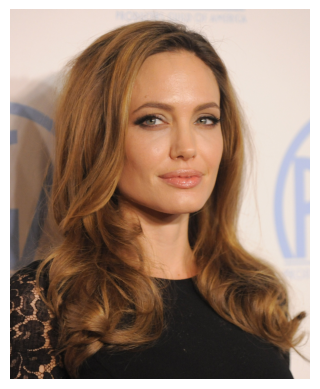

In [5]:
# 顯示圖像
plt.imshow(image)
plt.axis('off')
plt.show()

## 建立 MTCNN 物件，偵測臉部

In [6]:
# 建立 MTCNN 物件
mtcnn = MTCNN(
    image_size=160,
    margin=0,
    min_face_size=20,
    thresholds=[0.6, 0.7, 0.7],
    factor=0.709,
    post_process=True,
    device=device,
)

In [7]:
help(MTCNN)

Help on class MTCNN in module facenet_pytorch.models.mtcnn:

class MTCNN(torch.nn.modules.module.Module)
 |  MTCNN(image_size=160, margin=0, min_face_size=20, thresholds=[0.6, 0.7, 0.7], factor=0.709, post_process=True, select_largest=True, selection_method=None, keep_all=False, device=None)
 |
 |  MTCNN face detection module.
 |
 |  This class loads pretrained P-, R-, and O-nets and returns images cropped to include the face
 |  only, given raw input images of one of the following types:
 |      - PIL image or list of PIL images
 |      - numpy.ndarray (uint8) representing either a single image (3D) or a batch of images (4D).
 |  Cropped faces can optionally be saved to file
 |  also.
 |
 |  Keyword Arguments:
 |      image_size {int} -- Output image size in pixels. The image will be square. (default: {160})
 |      margin {int} -- Margin to add to bounding box, in terms of pixels in the final image.
 |          Note that the application of the margin differs slightly from the davidsa

## 辨識並裁切圖檔

In [8]:
# 辨識
image_cropped: torch.Tensor = mtcnn(image)
# 色彩通道在第一維，轉換至最後一維
image_cropped = torch.permute(image_cropped, (1, 2, 0))
# 限定像素值範圍介於 [0, 1]
image_cropped = image_cropped.clamp(-1, 1)
image_cropped = (image_cropped + 1) * 0.5  # 使像素值介於 [0, 1] 之間

## 顯示圖檔

In [9]:
type(image_cropped)

torch.Tensor

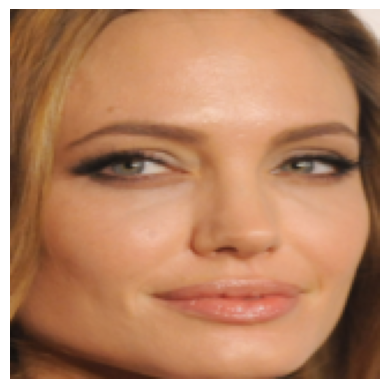

In [10]:
# 顯示圖像
plt.imshow(image_cropped)
plt.axis('off')
plt.show()

## 比較臉部相似性

In [11]:
# 建立 inception resnet 預先訓練模型
resnet = InceptionResnetV1(pretrained='vggface2').eval().to(device)

## 載入資料夾下所有影像

In [12]:
def collate_fn(x: List[Tuple[Image.Image, int]]) -> Tuple[Image.Image, int]:
    return x[0]


dataset = datasets.ImageFolder('MTCNN')
idx_to_class = {i: c for c, i in dataset.class_to_idx.items()}
loader = DataLoader(dataset, collate_fn=collate_fn)

## 使用MTCNN識別臉部，並取得臉部向量

In [13]:
aligned = []
names = []
for x, y in loader:
    x_aligned, prob = mtcnn(x, return_prob=True)
    if x_aligned is not None:
        print(f'臉部識別: {idx_to_class[y]} 機率: {prob:8f}')
        # 取得臉部向量
        aligned.append(x_aligned)
        # 取得姓名
        names.append(idx_to_class[y])

臉部識別: angelina_jolie 機率: 0.999983
臉部識別: bradley_cooper 機率: 0.999934
臉部識別: kate_siegel 機率: 0.999733
臉部識別: paul_rudd 機率: 0.999876
臉部識別: shea_whigham 機率: 0.999992


## 轉換為嵌入向量

In [14]:
aligned = torch.stack(aligned).to(device)
embeddings = cast(torch.Tensor, resnet(aligned)).detach().cpu()

## 比較嵌入向量相似性

In [15]:
# 計算夾角
dists = [[(e1 - e2).norm().item() for e2 in embeddings] for e1 in embeddings]
pd.DataFrame(dists, columns=names, index=names)

,angelina_jolie,bradley_cooper,kate_siegel,paul_rudd,shea_whigham
angelina_jolie,0.000000,1.447480,0.887728,1.434377,1.399073
bradley_cooper,1.447480,0.000000,1.313749,1.011980,1.038684
kate_siegel,0.887728,1.313749,0.000000,1.388993,1.379655
paul_rudd,1.434377,1.011980,1.388993,0.000000,1.104095
shea_whigham,1.399073,1.038684,1.379655,1.104095,0.000000


# 臉部追蹤

## 建立 MTCNN 物件

In [16]:
mtcnn = MTCNN(keep_all=True, device=device)

## 載入視訊，並撥放視訊

In [17]:
video_path = 'MTCNN/video.mp4'
video = mmcv.VideoReader(video_path)
frames = [Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)) for frame in video]

display.Video(video_path, width=640)

## 臉部追蹤

In [18]:
frames_tracked = []
for i, frame in enumerate(frames):
    print(f'\rTracking frame: {i + 1}', end='')

    # 臉部追蹤
    boxes = mtcnn.detect(frame)[0]

    # 臉部畫框
    frame_draw = frame.copy()
    draw = ImageDraw.Draw(frame_draw)
    for box in boxes:
        draw.rectangle(box.tolist(), outline=(255, 0, 0), width=6)

    # 存至 frames_tracked
    frames_tracked.append(frame_draw.resize((640, 360), Image.Resampling.BILINEAR))
print('\nDone')

Tracking frame: 105
Done


## 撥放臉部畫框的視訊

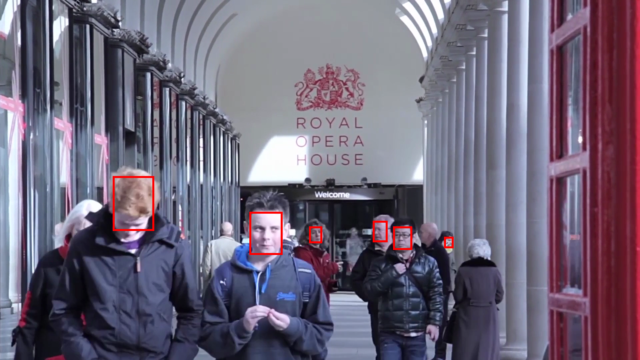

In [19]:
d = display.display(frames_tracked[0], display_id=True)
assert d is not None
loops = 3
try:
    for i in range(1, len(frames_tracked) * loops):
        d.update(frames_tracked[i % len(frames_tracked)])
except KeyboardInterrupt:
    pass

## 存檔

In [20]:
dim = frames_tracked[0].size
fourcc = cv2.VideoWriter.fourcc(*'mp4v')
raw_video_path = 'MTCNN/video_tracked_raw.mp4'
video_tracked = cv2.VideoWriter(raw_video_path, fourcc, 25.0, dim)
for frame in frames_tracked:
    video_tracked.write(cv2.cvtColor(np.array(frame), cv2.COLOR_RGB2BGR))
video_tracked.release()

# 轉碼為 H.264 / yuv420p，才能在瀏覽器與 VSCode 中正常播放
tracked_video_path = 'MTCNN/video_tracked.mp4'
subprocess.run(
    [
        'ffmpeg', '-y', '-i', raw_video_path,
        '-vcodec', 'libx264', '-pix_fmt', 'yuv420p',
        tracked_video_path,
    ],
    check=True,
)

ffmpeg version 8.1.2 Copyright (c) 2000-2026 the FFmpeg developers
  built with Apple clang version 21.0.0 (clang-2100.0.123.102)
  configuration: --prefix=/opt/homebrew/Cellar/ffmpeg/8.1.2_1 --enable-shared --enable-pthreads --enable-version3 --cc=clang --host-cflags= --host-ldflags= --enable-ffplay --enable-gpl --enable-libsvtav1 --enable-libopus --enable-libx264 --enable-libmp3lame --enable-libdav1d --enable-libvmaf --enable-libvpx --enable-libx265 --enable-openssl --enable-videotoolbox --enable-audiotoolbox --enable-neon
  libavutil      60. 26.102 / 60. 26.102
  libavcodec     62. 28.102 / 62. 28.102
  libavformat    62. 12.102 / 62. 12.102
  libavdevice    62.  3.102 / 62.  3.102
  libavfilter    11. 14.102 / 11. 14.102
  libswscale      9.  5.102 /  9.  5.102
  libswresample   6.  3.102 /  6.  3.102
Input #0, mov,mp4,m4a,3gp,3g2,mj2, from 'MTCNN/video_tracked_raw.mp4':
  Metadata:
    major_brand     : isom
    minor_version   : 512
    compatible_brands: isomiso2mp41
    encode

CompletedProcess(args=['ffmpeg', '-y', '-i', 'MTCNN/video_tracked_raw.mp4', '-vcodec', 'libx264', '-pix_fmt', 'yuv420p', 'MTCNN/video_tracked.mp4'], returncode=0)

In [21]:
display.Video(tracked_video_path, width=640)